# Geographic AI Exposure Maps

Presentation-quality choropleth maps showing the spatial distribution of AI exposure across the UK. These maps visualize how AI's economic impact varies by region, revealing the geographic fault lines of the AI transition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'store').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# Load data
geo_df = pd.read_csv(ROOT / "store/outputs/production_5m/production_5m/geo_lad.csv")
gdf = gpd.read_file(ROOT / "store/analysis/LAD_Dec_2022_UK_BGC.geojson")
merged = gdf.merge(geo_df, on='LAD22CD', how='left')
merged['geometry'] = merged['geometry'].simplify(tolerance=100)

OUT_DIR = ROOT / "store/analysis/figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Dark theme for presentation slides
DARK_BG = '#1a1a2e'
DARK_FG = '#e0e0e0'

# Task exposure score variants
SCORE_VARIANTS = {
    'absolute': {
        'col': 'task_exposure_mean',
        'label': 'Absolute Task Exposure',
        'label_short': 'Absolute',
    },
    'bt': {
        'col': 'task_exposure_bt_mean',
        'label': 'Bradley-Terry Task Exposure',
        'label_short': 'Bradley-Terry',
    },
}

print(f"Loaded {len(merged)} LADs, {merged['task_exposure_mean'].notna().sum()} with scores")

Loaded 374 LADs, 373 with scores


## Hero Maps: Dark Theme

Presentation-ready maps with dark backgrounds for both scoring methods. Individual maps are suitable for standalone slides; the side-by-side comparison shows how the two methods agree and diverge geographically.

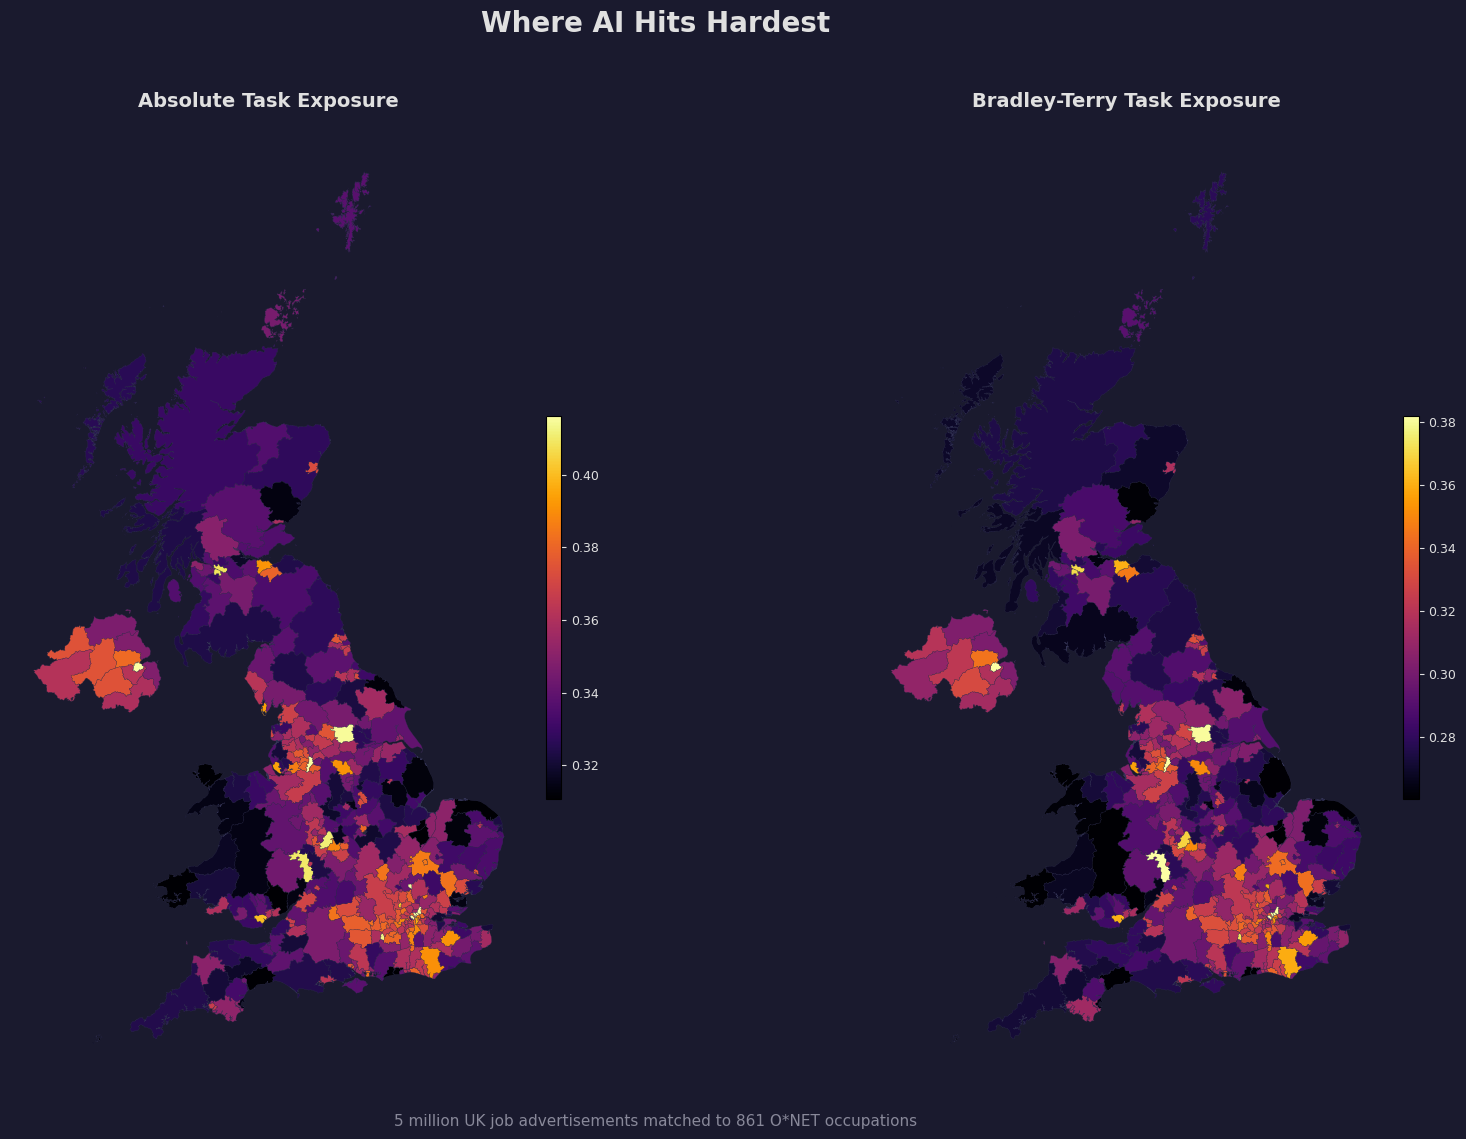

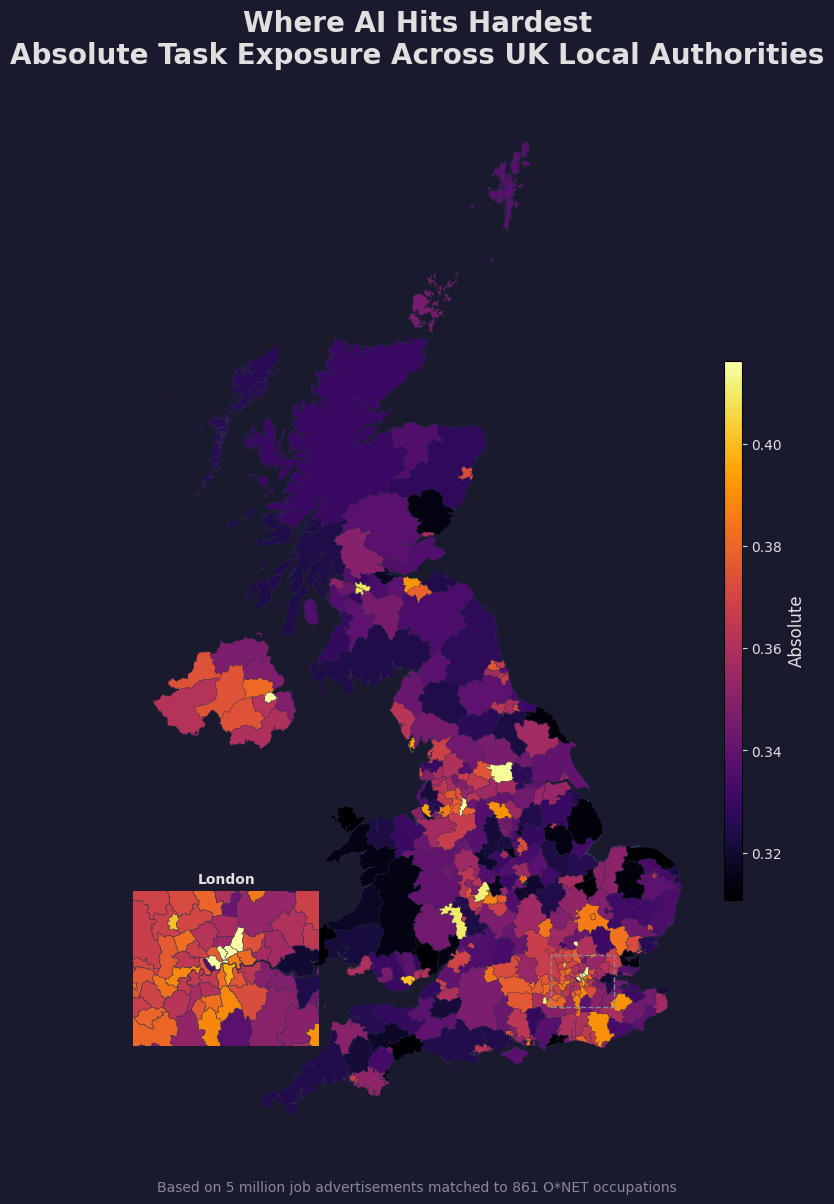

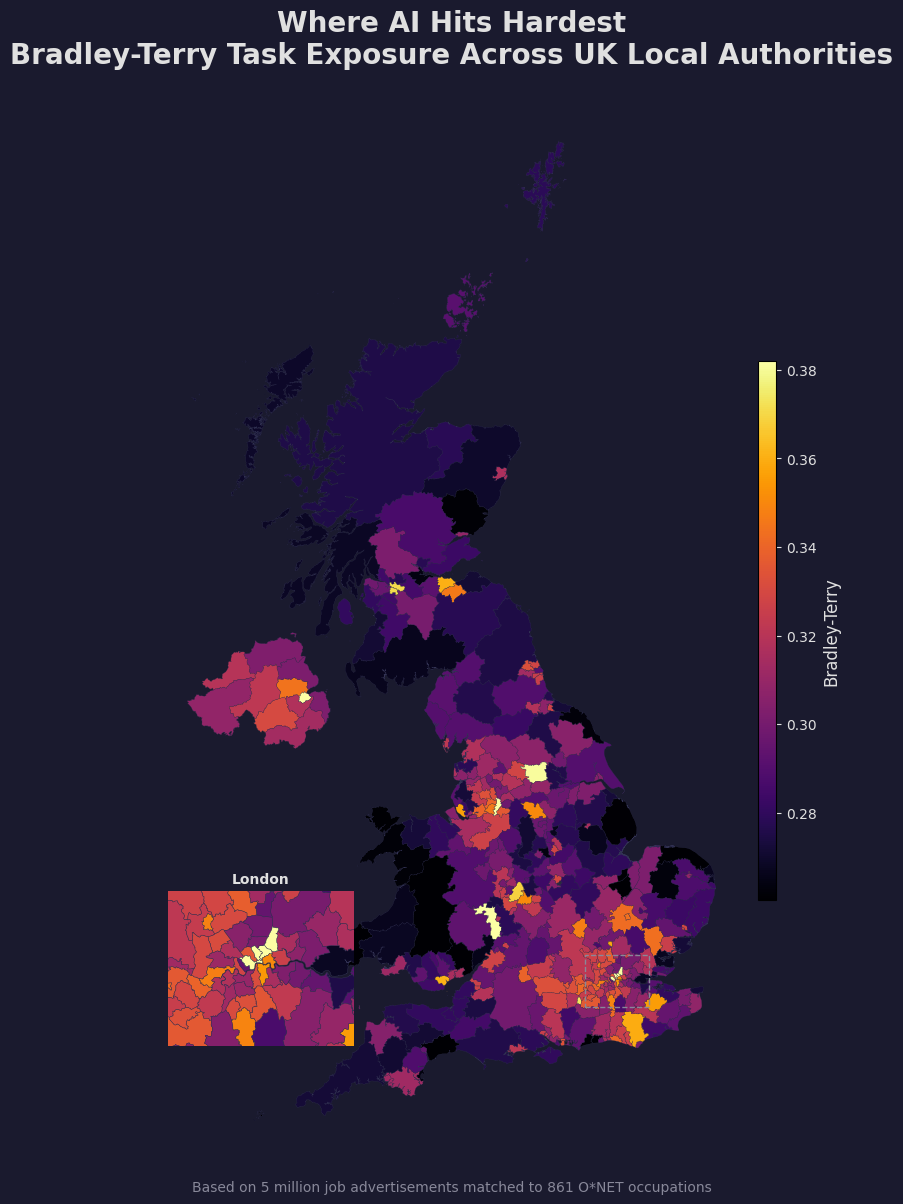

In [2]:
# --- Side-by-side hero maps ---
fig, axes = plt.subplots(1, 2, figsize=(18, 12), facecolor=DARK_BG)

for ax, (key, sv) in zip(axes, SCORE_VARIANTS.items()):
    col = sv['col']
    ax.set_facecolor(DARK_BG)
    
    unmatched = merged[merged[col].isna()]
    matched_gdf = merged[merged[col].notna()]
    vmin, vmax = matched_gdf[col].quantile(0.02), matched_gdf[col].quantile(0.98)
    
    if len(unmatched) > 0:
        unmatched.plot(ax=ax, color='#2a2a3e', edgecolor='#333355', linewidth=0.15)
    matched_gdf.plot(ax=ax, column=col, cmap='inferno', edgecolor='#333355', linewidth=0.15,
                     vmin=vmin, vmax=vmax, legend=True,
                     legend_kwds={'shrink': 0.4, 'pad': 0.02, 'aspect': 25})
    
    cb_ax = ax.get_figure().axes[-1]
    cb_ax.tick_params(colors=DARK_FG, labelsize=9)
    
    ax.set_axis_off()
    ax.set_title(sv['label'], fontsize=14, fontweight='bold', color=DARK_FG, pad=15)

fig.suptitle('Where AI Hits Hardest', fontsize=20, fontweight='bold', color=DARK_FG, y=0.95)
fig.text(0.5, 0.02, '5 million UK job advertisements matched to 861 O*NET occupations',
         fontsize=11, ha='center', color='#888899')
plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.savefig(OUT_DIR / "hero_map_dark_comparison.png", dpi=300, bbox_inches='tight',
            facecolor=DARK_BG, edgecolor='none')
plt.show()

# --- Individual hero maps with London inset ---
for key, sv in SCORE_VARIANTS.items():
    col = sv['col']
    fig, ax = plt.subplots(1, 1, figsize=(10, 14), facecolor=DARK_BG)
    ax.set_facecolor(DARK_BG)
    
    unmatched = merged[merged[col].isna()]
    matched_gdf = merged[merged[col].notna()]
    vmin, vmax = matched_gdf[col].quantile(0.02), matched_gdf[col].quantile(0.98)
    
    if len(unmatched) > 0:
        unmatched.plot(ax=ax, color='#2a2a3e', edgecolor='#333355', linewidth=0.2)
    matched_gdf.plot(ax=ax, column=col, cmap='inferno', edgecolor='#333355', linewidth=0.15,
                     vmin=vmin, vmax=vmax, legend=True,
                     legend_kwds={'label': '', 'shrink': 0.5, 'pad': 0.02, 'aspect': 30})
    
    cbar = ax.get_figure().axes[-1]
    cbar.tick_params(colors=DARK_FG, labelsize=10)
    cbar.set_ylabel(sv['label_short'], color=DARK_FG, fontsize=12)
    
    ax.set_axis_off()
    ax.set_title(f'Where AI Hits Hardest\n{sv["label"]} Across UK Local Authorities',
                 fontsize=20, fontweight='bold', color=DARK_FG, pad=20)
    ax.text(0.5, -0.02, 'Based on 5 million job advertisements matched to 861 O*NET occupations',
            transform=ax.transAxes, fontsize=10, ha='center', color='#888899')
    
    # London inset
    ax_inset = inset_axes(ax, width="32%", height="32%", loc='lower left',
                           bbox_to_anchor=(0.0, 0.02, 1, 1), bbox_transform=ax.transAxes)
    ax_inset.set_facecolor(DARK_BG)
    london = merged[merged['LAD22CD'].str.startswith('E09')]
    lb = london.total_bounds; pad = 10000
    ax_inset.set_xlim(lb[0]-pad, lb[2]+pad)
    ax_inset.set_ylim(lb[1]-pad, lb[3]+pad)
    merged.plot(ax=ax_inset, column=col, cmap='inferno', edgecolor='#333355', linewidth=0.3,
                vmin=vmin, vmax=vmax, missing_kwds={'color': '#2a2a3e'})
    ax_inset.set_axis_off()
    ax_inset.set_title('London', fontsize=10, fontweight='bold', color=DARK_FG)
    for spine in ax_inset.spines.values():
        spine.set_edgecolor('#555577'); spine.set_linewidth(1); spine.set_visible(True)
    
    rect = Rectangle((lb[0]-pad, lb[1]-pad), lb[2]-lb[0]+2*pad, lb[3]-lb[1]+2*pad,
                      linewidth=1, edgecolor='#888899', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    
    plt.savefig(OUT_DIR / f"hero_map_dark_{key}.png", dpi=300, bbox_inches='tight',
                facecolor=DARK_BG, edgecolor='none')
    plt.show()

## Side-by-Side: Task Exposure vs Physical Presence

These maps show the inverse geographic pattern between AI task exposure and physical presence requirements. Produced for both scoring methods.

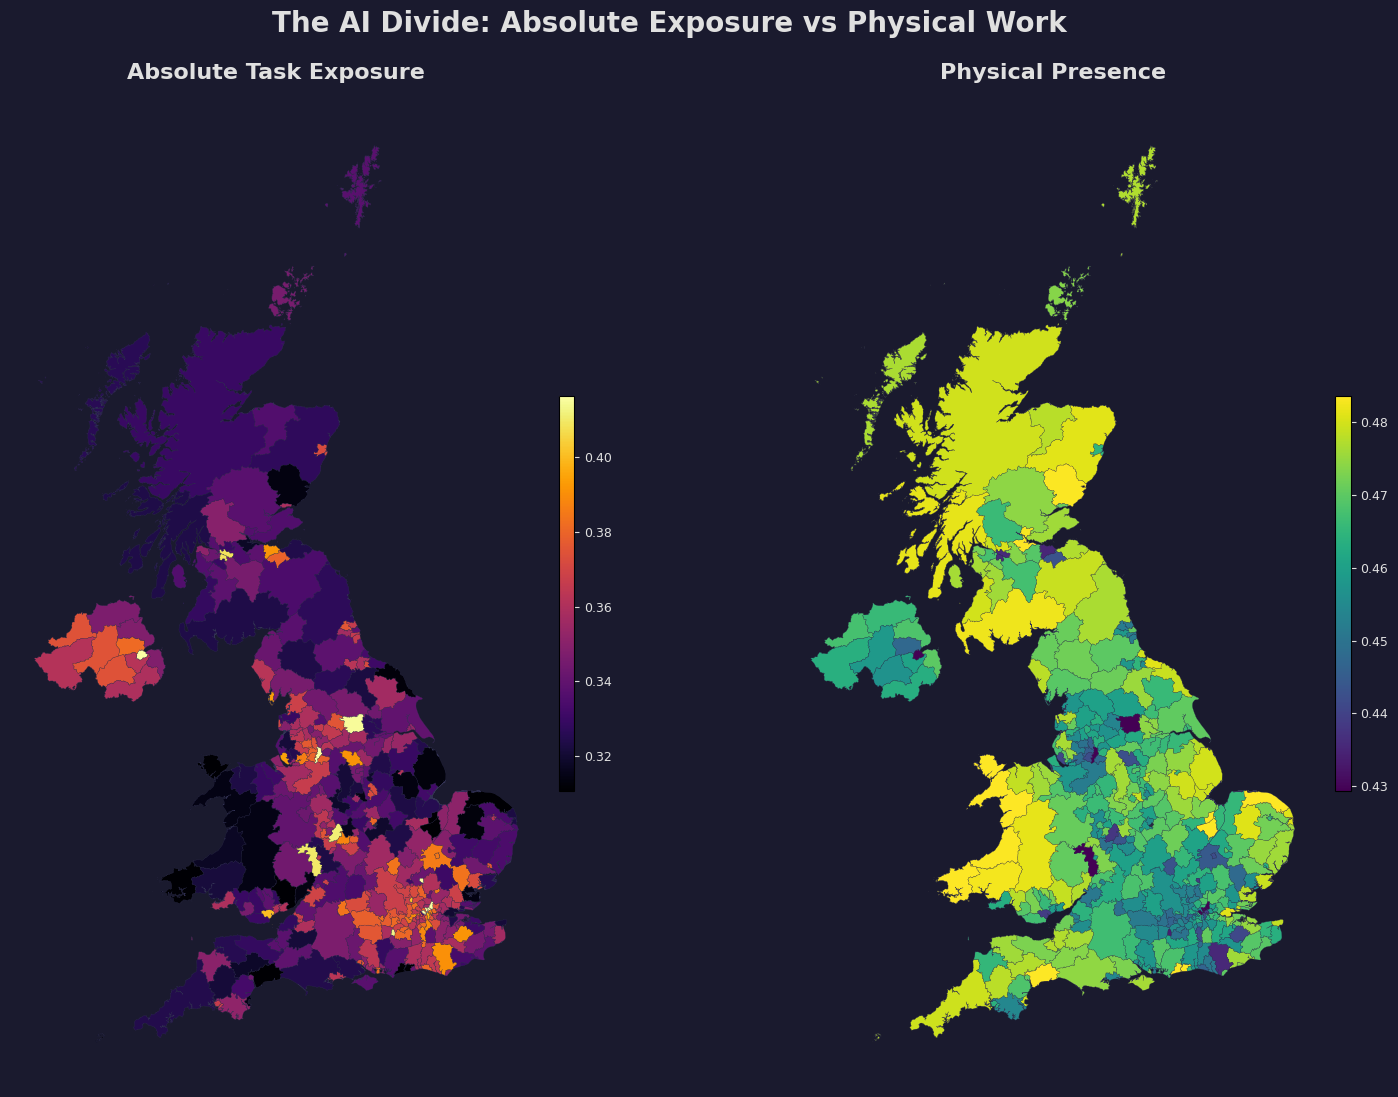

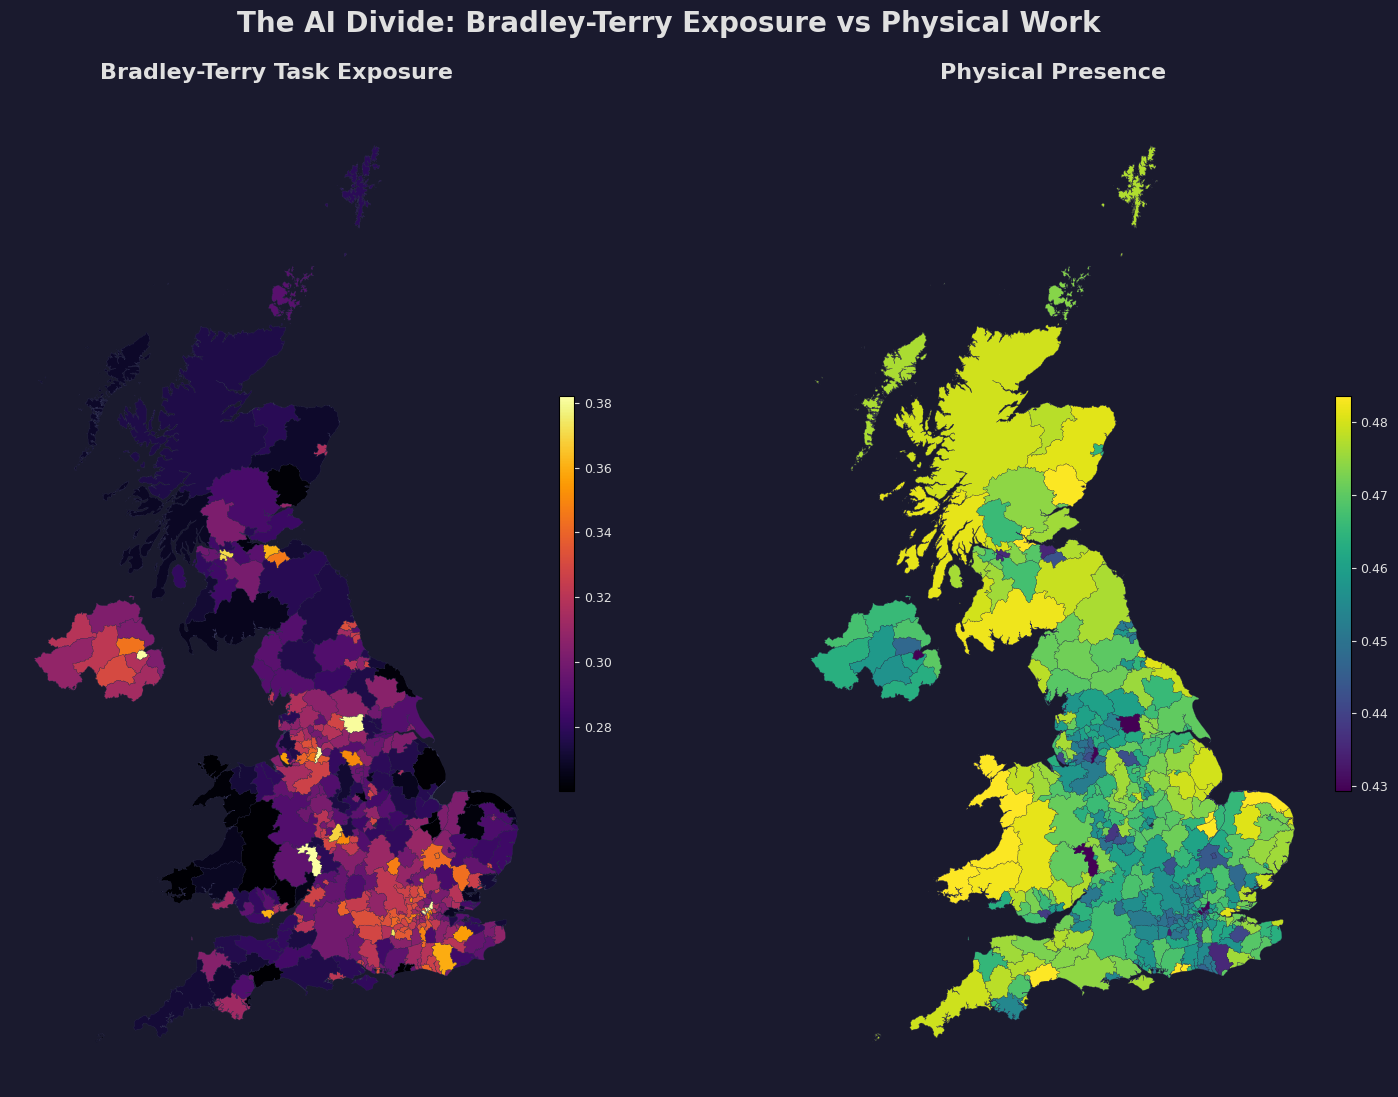

In [3]:
# Exposure vs Physical Presence for both variants
for key, sv in SCORE_VARIANTS.items():
    col = sv['col']
    fig, axes = plt.subplots(1, 2, figsize=(16, 12), facecolor=DARK_BG)
    
    panels = [
        (col, sv['label'], 'inferno'),
        ('presence_physical', 'Physical Presence', 'viridis'),
    ]
    
    for ax, (pcol, title, cmap) in zip(axes, panels):
        ax.set_facecolor(DARK_BG)
        data = merged[merged[pcol].notna()]
        missing = merged[merged[pcol].isna()]
        vmin, vmax = data[pcol].quantile(0.02), data[pcol].quantile(0.98)
        
        if len(missing) > 0:
            missing.plot(ax=ax, color='#2a2a3e', edgecolor='#333355', linewidth=0.15)
        data.plot(ax=ax, column=pcol, cmap=cmap, edgecolor='#333355', linewidth=0.15,
                  vmin=vmin, vmax=vmax, legend=True,
                  legend_kwds={'shrink': 0.4, 'pad': 0.02, 'aspect': 25})
        
        cb_ax = ax.get_figure().axes[-1]
        cb_ax.tick_params(colors=DARK_FG, labelsize=9)
        ax.set_axis_off()
        ax.set_title(title, fontsize=16, fontweight='bold', color=DARK_FG, pad=15)
    
    fig.suptitle(f'The AI Divide: {sv["label_short"]} Exposure vs Physical Work',
                 fontsize=20, fontweight='bold', color=DARK_FG, y=0.95)
    plt.tight_layout(rect=[0, 0.04, 1, 0.93])
    plt.savefig(OUT_DIR / f"dual_map_exposure_vs_presence_{key}.png", dpi=300, bbox_inches='tight',
                facecolor=DARK_BG, edgecolor='none')
    plt.show()

**Observations:**
- The two maps show a clear inverse geographic pattern. London and major cities glow bright on the left (high AI task exposure) but are darker on the right (lower physical presence). Rural areas and Scotland show the opposite pattern.
- **Caveat**: physical presence varies over a narrow absolute range at LAD level (0.42--0.48), so the color scale amplifies small differences. The visual contrast is stronger than the quantitative one. Task exposure has roughly 5x more geographic variation than physical presence.

## Vulnerability Map

A composite vulnerability score combining high task exposure with low presence. This identifies areas where jobs are both highly automatable *and* have few human-presence barriers to adoption.

In [4]:
# Compute vulnerability for both variants
for key, sv in SCORE_VARIANTS.items():
    col = sv['col']
    te = merged[col]
    pc = merged['presence_composite']
    te_norm = (te - te.min()) / (te.max() - te.min())
    pc_norm = (pc - pc.min()) / (pc.max() - pc.min())
    merged[f'vulnerability_{key}'] = te_norm * (1 - pc_norm)
    
    vuln = merged[f'vulnerability_{key}'].dropna()
    print(f"{sv['label']} vulnerability: min={vuln.min():.4f}, max={vuln.max():.4f}, mean={vuln.mean():.4f}")
    top3 = merged.nlargest(3, f'vulnerability_{key}')[['LAD22NM_x', f'vulnerability_{key}', col, 'presence_composite']]
    print(top3.to_string(index=False))
    print()

Absolute Task Exposure vulnerability: min=0.0000, max=0.3251, mean=0.1439
              LAD22NM_x  vulnerability_absolute  task_exposure_mean  presence_composite
                Belfast                0.325128            0.425189            0.518060
      City of Edinburgh                0.282565            0.391164            0.515758
Antrim and Newtownabbey                0.276927            0.381330            0.514293

Bradley-Terry Task Exposure vulnerability: min=0.0000, max=0.3211, mean=0.1236
        LAD22NM_x  vulnerability_bt  task_exposure_bt_mean  presence_composite
          Belfast          0.321100               0.401685            0.518060
City of Edinburgh          0.275190               0.360312            0.515758
      Westminster          0.264938               0.397296            0.520789



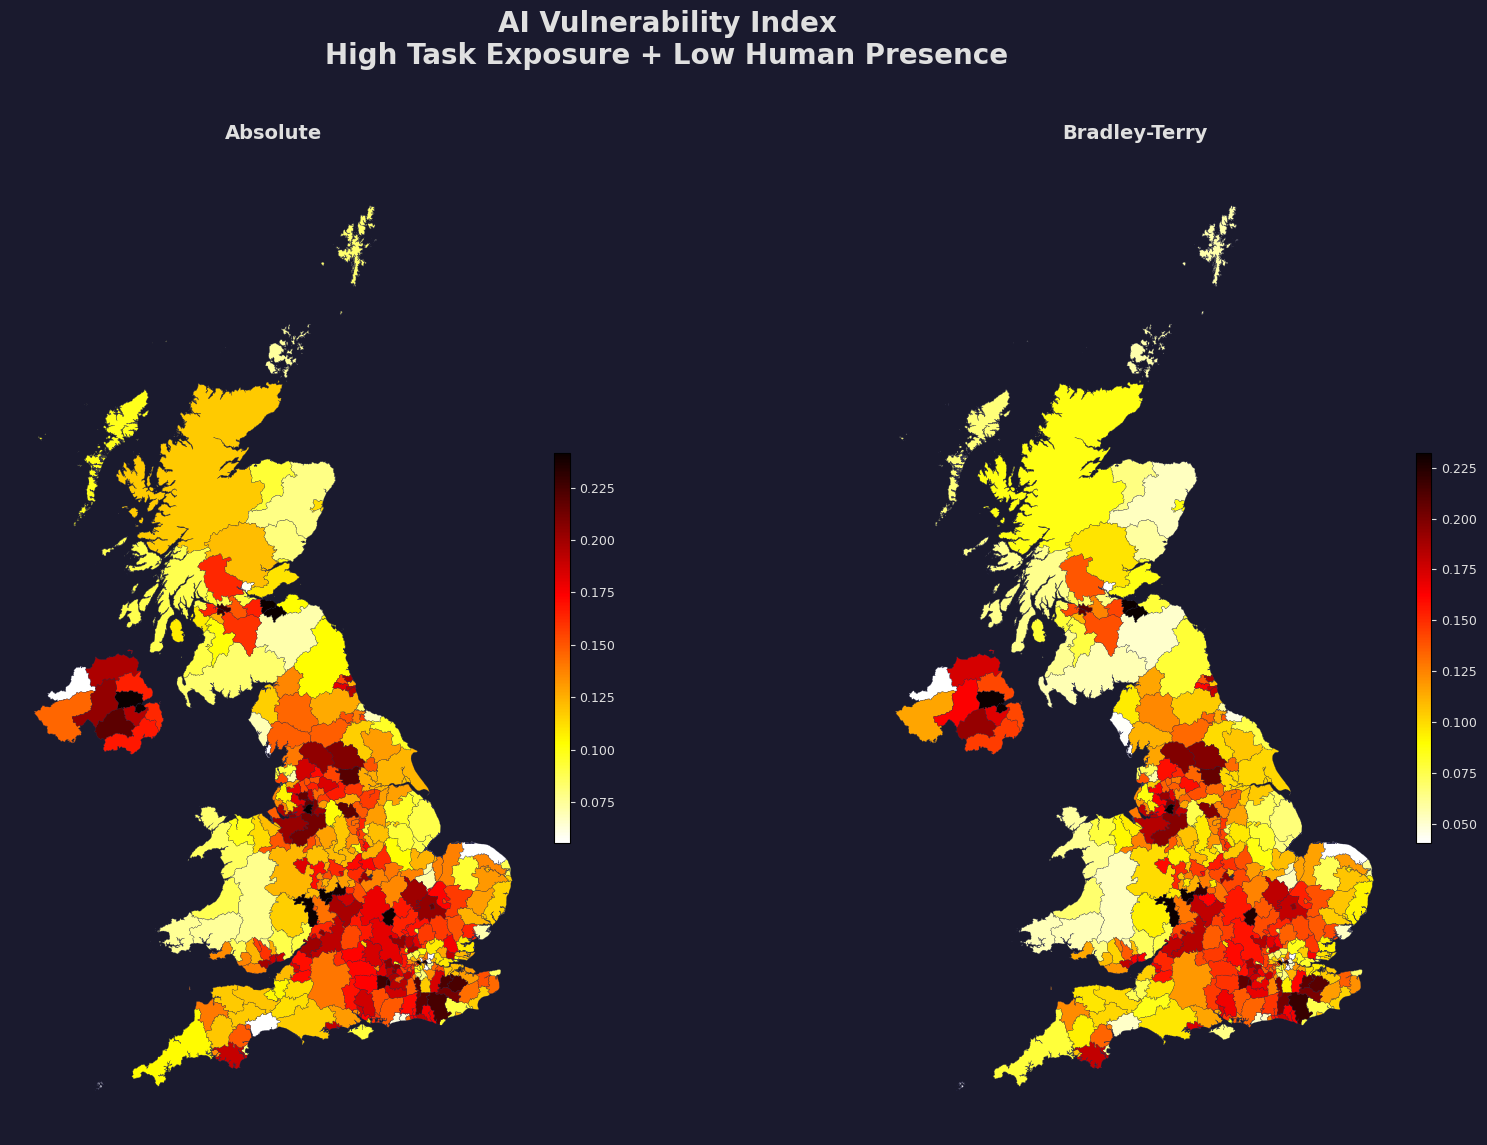

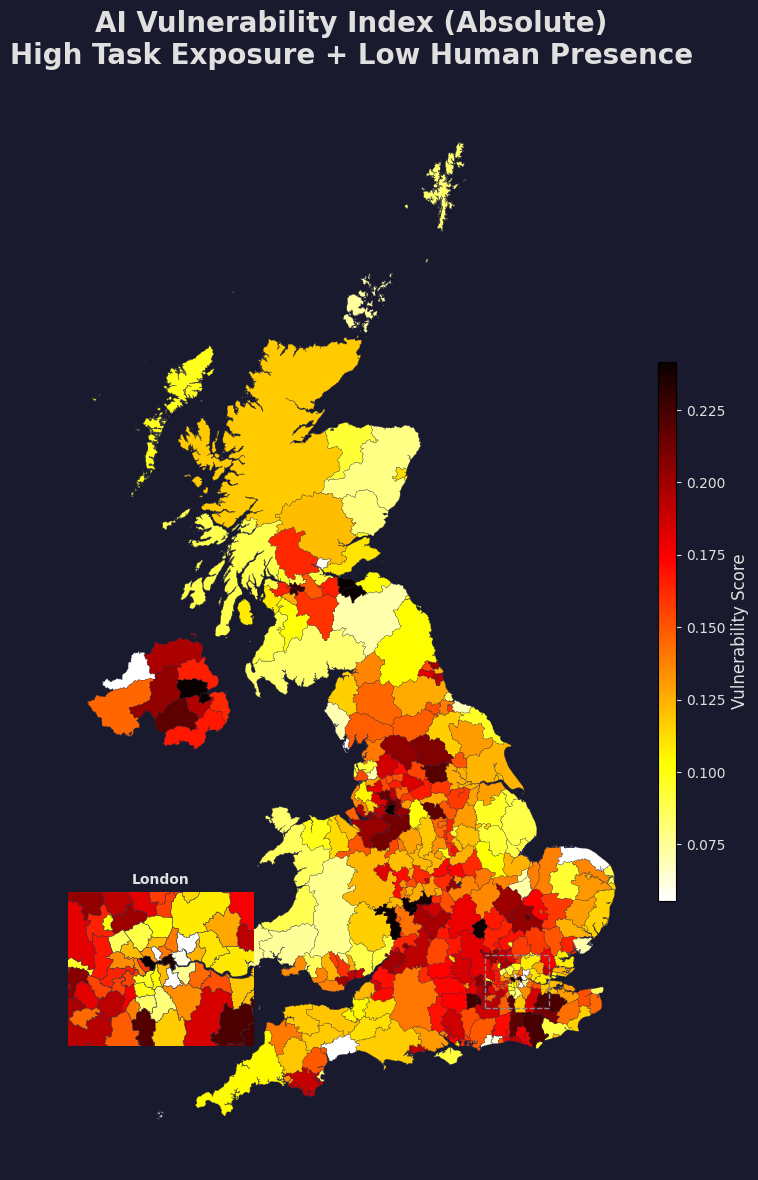

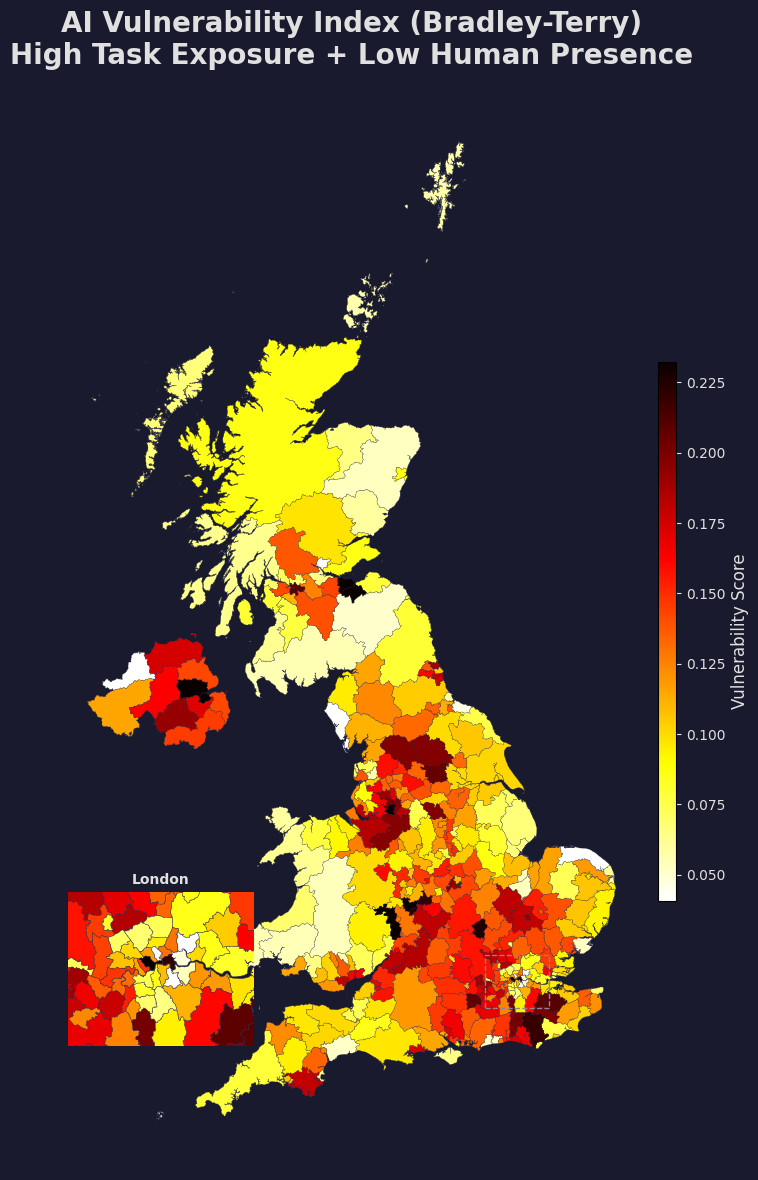

In [5]:
# --- Side-by-side vulnerability maps ---
fig, axes = plt.subplots(1, 2, figsize=(18, 12), facecolor=DARK_BG)

for ax, (key, sv) in zip(axes, SCORE_VARIANTS.items()):
    vuln_col = f'vulnerability_{key}'
    ax.set_facecolor(DARK_BG)
    
    data = merged[merged[vuln_col].notna()]
    missing = merged[merged[vuln_col].isna()]
    if len(missing) > 0:
        missing.plot(ax=ax, color='#2a2a3e', edgecolor='#333355', linewidth=0.15)
    
    vmin, vmax = data[vuln_col].quantile(0.02), data[vuln_col].quantile(0.98)
    data.plot(ax=ax, column=vuln_col, cmap='hot_r', edgecolor='#333355', linewidth=0.15,
              vmin=vmin, vmax=vmax, legend=True, legend_kwds={'shrink': 0.4, 'pad': 0.02, 'aspect': 25})
    
    cb_ax = ax.get_figure().axes[-1]
    cb_ax.tick_params(colors=DARK_FG, labelsize=9)
    
    ax.set_axis_off()
    ax.set_title(sv['label_short'], fontsize=14, fontweight='bold', color=DARK_FG, pad=15)

fig.suptitle('AI Vulnerability Index\nHigh Task Exposure + Low Human Presence',
             fontsize=20, fontweight='bold', color=DARK_FG, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / "vulnerability_map_dark_comparison.png", dpi=300, bbox_inches='tight',
            facecolor=DARK_BG, edgecolor='none')
plt.show()

# --- Individual vulnerability maps with London inset ---
for key, sv in SCORE_VARIANTS.items():
    vuln_col = f'vulnerability_{key}'
    fig, ax = plt.subplots(1, 1, figsize=(10, 14), facecolor=DARK_BG)
    ax.set_facecolor(DARK_BG)
    
    data = merged[merged[vuln_col].notna()]
    missing = merged[merged[vuln_col].isna()]
    if len(missing) > 0:
        missing.plot(ax=ax, color='#2a2a3e', edgecolor='#333355', linewidth=0.2)
    
    vmin, vmax = data[vuln_col].quantile(0.02), data[vuln_col].quantile(0.98)
    data.plot(ax=ax, column=vuln_col, cmap='hot_r', edgecolor='#333355', linewidth=0.15,
              vmin=vmin, vmax=vmax, legend=True,
              legend_kwds={'shrink': 0.5, 'pad': 0.02, 'aspect': 30})
    
    cbar = ax.get_figure().axes[-1]
    cbar.tick_params(colors=DARK_FG, labelsize=10)
    cbar.set_ylabel('Vulnerability Score', color=DARK_FG, fontsize=12)
    
    ax.set_axis_off()
    ax.set_title(f'AI Vulnerability Index ({sv["label_short"]})\nHigh Task Exposure + Low Human Presence',
                 fontsize=20, fontweight='bold', color=DARK_FG, pad=20)
    
    # London inset
    ax_inset = inset_axes(ax, width="32%", height="32%", loc='lower left',
                           bbox_to_anchor=(0.0, 0.02, 1, 1), bbox_transform=ax.transAxes)
    ax_inset.set_facecolor(DARK_BG)
    london = merged[merged['LAD22CD'].str.startswith('E09')]
    lb = london.total_bounds; pad = 10000
    ax_inset.set_xlim(lb[0]-pad, lb[2]+pad)
    ax_inset.set_ylim(lb[1]-pad, lb[3]+pad)
    merged.plot(ax=ax_inset, column=vuln_col, cmap='hot_r', edgecolor='#333355', linewidth=0.3,
                vmin=vmin, vmax=vmax, missing_kwds={'color': '#2a2a3e'})
    ax_inset.set_axis_off()
    ax_inset.set_title('London', fontsize=10, fontweight='bold', color=DARK_FG)
    for spine in ax_inset.spines.values():
        spine.set_edgecolor('#555577'); spine.set_linewidth(1); spine.set_visible(True)
    
    rect = Rectangle((lb[0]-pad, lb[1]-pad), lb[2]-lb[0]+2*pad, lb[3]-lb[1]+2*pad,
                      linewidth=1, edgecolor='#888899', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    
    plt.savefig(OUT_DIR / f"vulnerability_map_dark_{key}.png", dpi=300, bbox_inches='tight',
                facecolor=DARK_BG, edgecolor='none')
    plt.show()

## Full LAD Rankings

All 373 LADs ranked by task exposure, showing the continuous distribution and highlighting key areas. Produced for both scoring methods.

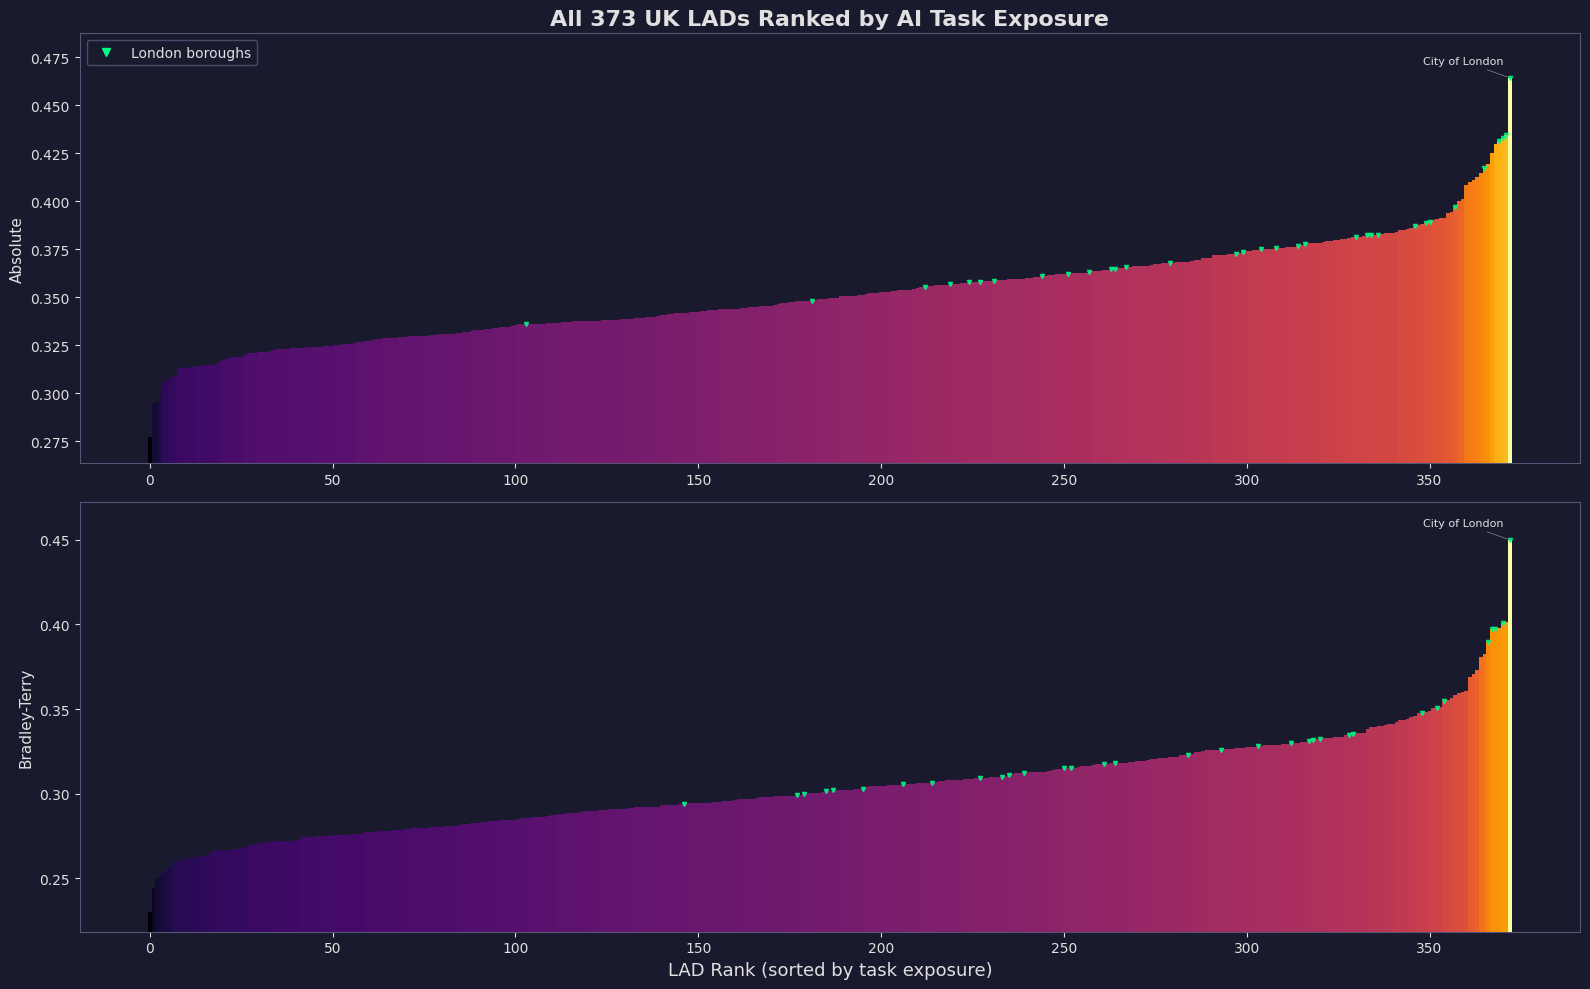

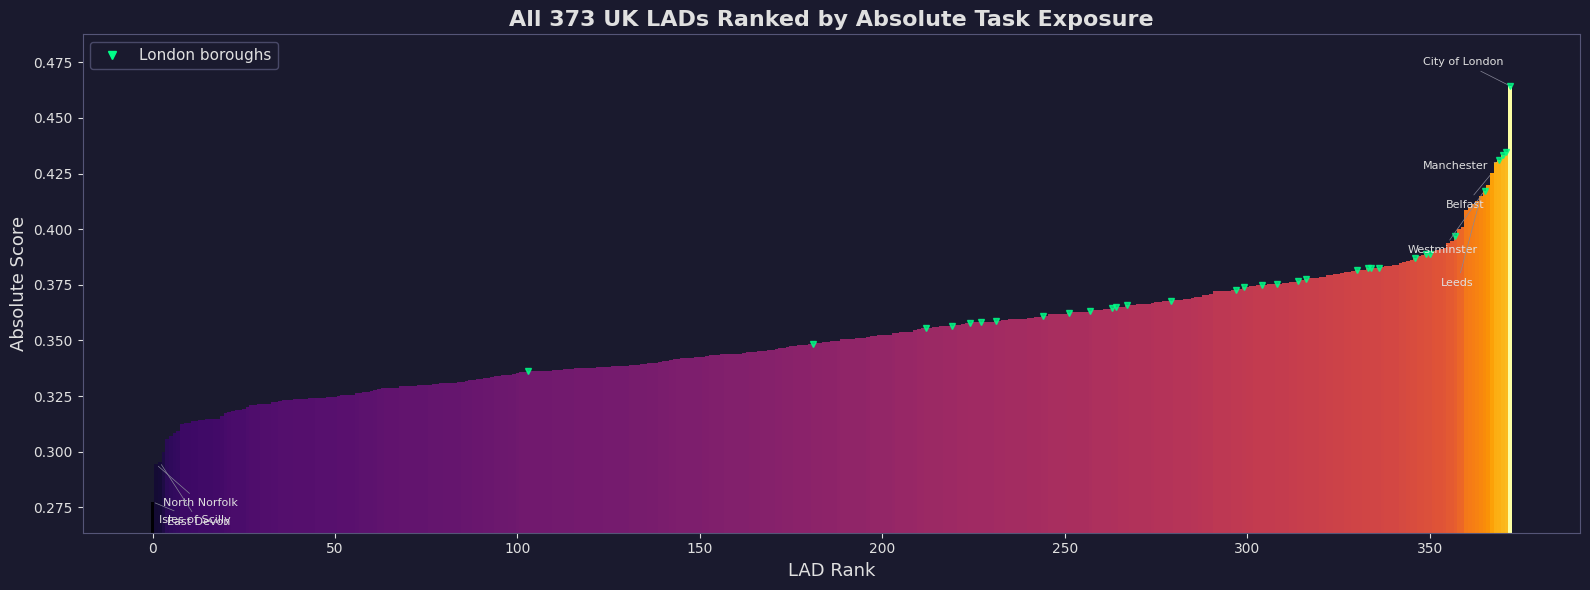

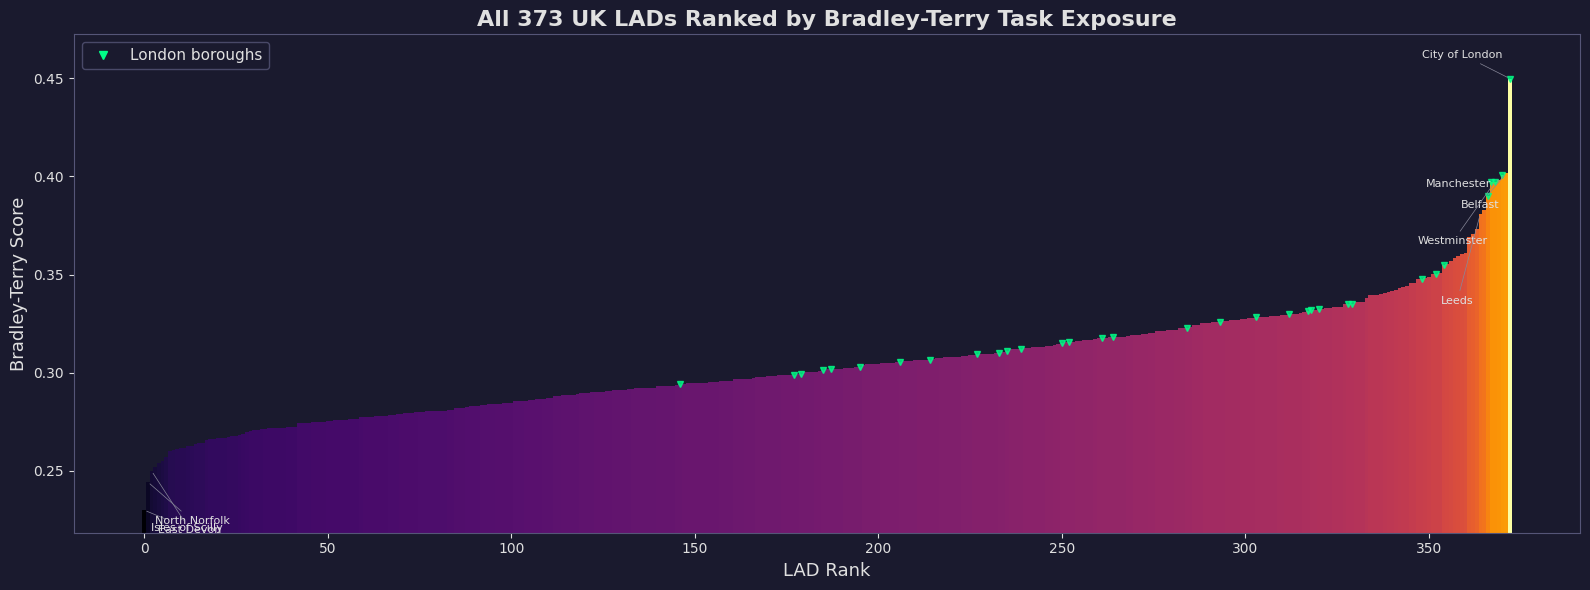

In [6]:
# --- Side-by-side LAD ranking ---
fig, axes = plt.subplots(2, 1, figsize=(16, 10), facecolor=DARK_BG)

for ax, (key, sv) in zip(axes, SCORE_VARIANTS.items()):
    col = sv['col']
    ranked = geo_df.sort_values(col, ascending=True).reset_index(drop=True)
    
    ax.set_facecolor(DARK_BG)
    norm = plt.Normalize(ranked[col].min(), ranked[col].max())
    colors = plt.cm.inferno(norm(ranked[col]))
    ax.bar(range(len(ranked)), ranked[col], width=1.0, color=colors, edgecolor='none')
    
    ymin = ranked[col].min() * 0.95
    ymax = ranked[col].max() * 1.05
    ax.set_ylim(ymin, ymax)
    
    # Label City of London
    idx = ranked[ranked['LAD22NM'] == 'City of London'].index
    if len(idx) > 0:
        i = idx[0]; val = ranked.loc[i, col]
        ax.annotate('City of London', (i, val), fontsize=8, color=DARK_FG,
                    textcoords='offset points', xytext=(-5, 10),
                    arrowprops=dict(arrowstyle='-', color='#888899', lw=0.5), ha='right')
    
    # Mark London boroughs
    london_mask = ranked['LAD22CD'].str.startswith('E09')
    for i in ranked[london_mask].index:
        ax.plot(i, ranked.loc[i, col], 'v', color='#00ff88', markersize=3, alpha=0.8)
    
    ax.set_ylabel(sv['label_short'], fontsize=11, color=DARK_FG)
    ax.tick_params(colors=DARK_FG)
    for spine in ax.spines.values():
        spine.set_color('#555577')

axes[0].set_title('All 373 UK LADs Ranked by AI Task Exposure', fontsize=16, fontweight='bold', color=DARK_FG)
axes[1].set_xlabel('LAD Rank (sorted by task exposure)', fontsize=13, color=DARK_FG)

# Legend
axes[0].plot([], [], 'v', color='#00ff88', markersize=6, label='London boroughs')
axes[0].legend(fontsize=10, facecolor=DARK_BG, edgecolor='#555577', labelcolor=DARK_FG)

plt.tight_layout()
plt.savefig(OUT_DIR / "lad_ranking_strip_comparison.png", dpi=300, bbox_inches='tight',
            facecolor=DARK_BG, edgecolor='none')
plt.show()

# --- Individual ranking plots ---
highlight_lads_right = ['City of London', 'Manchester', 'Belfast', 'Westminster', 'Leeds']
highlight_lads_left = ['Isles of Scilly', 'North Norfolk', 'East Devon']

for key, sv in SCORE_VARIANTS.items():
    col = sv['col']
    ranked = geo_df.sort_values(col, ascending=True).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(16, 6), facecolor=DARK_BG)
    ax.set_facecolor(DARK_BG)
    
    norm = plt.Normalize(ranked[col].min(), ranked[col].max())
    colors = plt.cm.inferno(norm(ranked[col]))
    ax.bar(range(len(ranked)), ranked[col], width=1.0, color=colors, edgecolor='none')
    ax.set_ylim(ranked[col].min() * 0.95, ranked[col].max() * 1.05)
    
    for lad_name, y_off in zip(highlight_lads_left, [-15, -30, -45]):
        idx = ranked[ranked['LAD22NM'] == lad_name].index
        if len(idx) > 0:
            i = idx[0]; val = ranked.loc[i, col]
            ax.annotate(lad_name, (i, val), fontsize=8, color=DARK_FG,
                        textcoords='offset points', xytext=(5, y_off),
                        arrowprops=dict(arrowstyle='-', color='#888899', lw=0.5), ha='left')
    
    for lad_name, y_off in zip(highlight_lads_right, [15, -5, -25, -45, -65]):
        idx = ranked[ranked['LAD22NM'] == lad_name].index
        if len(idx) > 0:
            i = idx[0]; val = ranked.loc[i, col]
            ax.annotate(lad_name, (i, val), fontsize=8, color=DARK_FG,
                        textcoords='offset points', xytext=(-5, y_off),
                        arrowprops=dict(arrowstyle='-', color='#888899', lw=0.5), ha='right')
    
    london_mask = ranked['LAD22CD'].str.startswith('E09')
    for i in ranked[london_mask].index:
        ax.plot(i, ranked.loc[i, col], 'v', color='#00ff88', markersize=4, alpha=0.8)
    
    ax.set_xlabel('LAD Rank', fontsize=13, color=DARK_FG)
    ax.set_ylabel(sv['label_short'] + ' Score', fontsize=13, color=DARK_FG)
    ax.set_title(f'All 373 UK LADs Ranked by {sv["label"]}', fontsize=16, fontweight='bold', color=DARK_FG)
    ax.plot([], [], 'v', color='#00ff88', markersize=6, label='London boroughs')
    ax.legend(fontsize=11, facecolor=DARK_BG, edgecolor='#555577', labelcolor=DARK_FG)
    ax.tick_params(colors=DARK_FG)
    for spine in ax.spines.values():
        spine.set_color('#555577')
    
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"lad_ranking_strip_{key}.png", dpi=300, bbox_inches='tight',
                facecolor=DARK_BG, edgecolor='none')
    plt.show()